In [ ]:
import pandas as pd

Vendas = pd.read_csv('/content/vendas.csv')
clientes = pd.read_csv('/content/clientes.csv' )


Vendas.head()

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1


In [ ]:
Vendas['faturamento'] = Vendas['quantidade'] * Vendas['valor_venda']

Vendas.to_csv('vendas_com_faturamento.csv', index=False)
Vendas.head()

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade,faturamento
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2,5354.24
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1,1210.10
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2,4786.12
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3,11777.76
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1,4702.89


In [ ]:
Vendas.info()
Vendas['data_venda'] = pd.to_datetime(Vendas["data_venda"])
Vendas.info()
Vendas['Mes'] = Vendas['data_venda'].dt.month
Vendas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda     120 non-null    int64  
 1   data_venda   120 non-null    object 
 2   id_cliente   120 non-null    int64  
 3   id_produto   120 non-null    int64  
 4   produto      120 non-null    object 
 5   categoria    120 non-null    object 
 6   valor_venda  120 non-null    float64
 7   quantidade   120 non-null    int64  
 8   faturamento  120 non-null    float64
dtypes: float64(2), int64(4), object(3)
memory usage: 8.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     120 non-null    int64         
 1   data_venda   120 non-null    datetime64[ns]
 2   id_cliente   120 non-null    int64         
 3   id_produto   120 n

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade,faturamento,Mes
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2,5354.24,2
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1,1210.10,1
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2,4786.12,2
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3,11777.76,3
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1,4702.89,2


In [ ]:
Faturamento_mes = Vendas.groupby('Mes', as_index=False)['faturamento'].sum()

Faturamento_mes['crescimento_pct'] = (
    Faturamento_mes['faturamento'].pct_change() * 100
)

Faturamento_mes

,Mes,faturamento,crescimento_pct
0,1,234634.61,NaN
1,2,282351.34,20.336612
2,3,293842.93,4.069961


In [ ]:
faturamento_categoria = Vendas.groupby('categoria', as_index=False)['faturamento'].sum()

total_faturamento = faturamento_categoria['faturamento'].sum()

faturamento_categoria['Participacao'] = (
    faturamento_categoria['faturamento'] / total_faturamento * 100
)

faturamento_categoria

,categoria,faturamento,Participacao
0,Colecionáveis,55658.46,6.864390
1,Componentes,35468.07,4.374298
2,Decoração,109156.43,13.462326
3,Eletrônicos,124973.54,15.413060
4,Livros,140285.75,17.301524
5,Móveis,8083.34,0.996923
6,Periféricos,307921.82,37.976178
7,Áudio,29281.47,3.611301


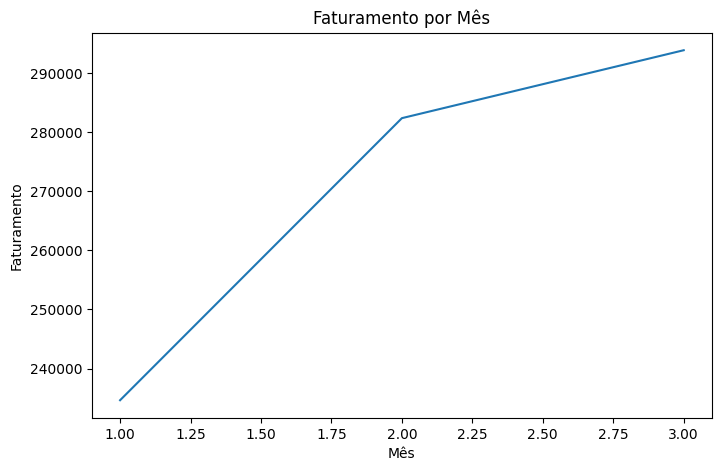

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    Faturamento_mes['Mes'],
    Faturamento_mes['faturamento']
)

plt.title('Faturamento por Mês')
plt.xlabel('Mês')
plt.ylabel('Faturamento')

plt.show()

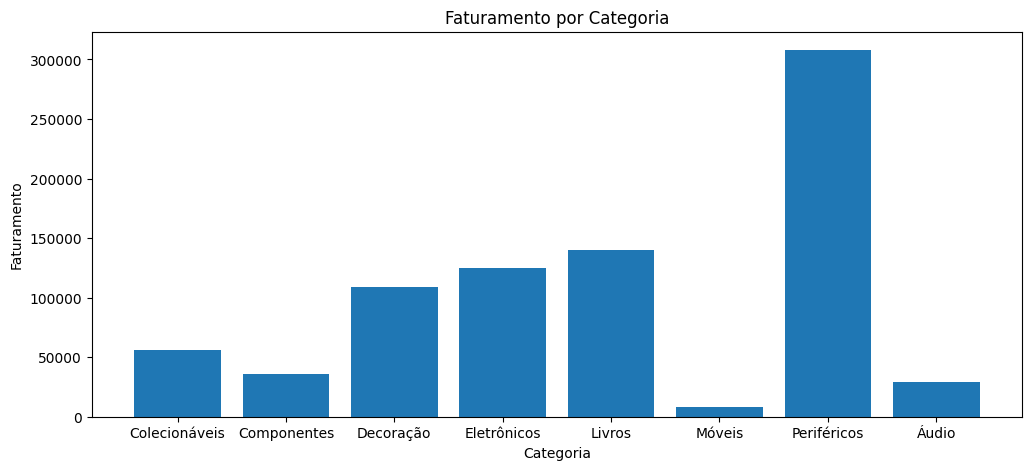

In [ ]:
plt.figure(figsize=(12,5))

plt.bar(
    faturamento_categoria['categoria'],
    faturamento_categoria['faturamento']
)

plt.title('Faturamento por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento')

plt.show()

In [ ]:
Vendas.head()

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade,faturamento,Mes
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2,5354.24,2
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1,1210.10,1
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2,4786.12,2
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3,11777.76,3
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1,4702.89,2


In [ ]:
clientes.to_csv('clientess.csv', index=False)


NameError: name 'VendasAttt' is not defined

In [ ]:
Vendas.to_csv('VendasAtt.csv', index=False, encoding='utf-8')

In [ ]:
Vendas.to_csv('VendasSepVirgula.csv', index=False, encoding='utf-8-sig', sep=';')

In [ ]:
df = pd.read_csv('VendasSepVirgula.csv', encoding='utf-8-sig', sep=';')
df.head()

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade,faturamento,Mes
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2,5354.24,2
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1,1210.10,1
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2,4786.12,2
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3,11777.76,3
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1,4702.89,2


In [ ]:
df = pd.read_csv('VendasSepVirgula.csv', sep=';', encoding='utf-8-sig')
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda     120 non-null    int64  
 1   data_venda   120 non-null    object 
 2   id_cliente   120 non-null    int64  
 3   id_produto   120 non-null    int64  
 4   produto      120 non-null    object 
 5   categoria    120 non-null    object 
 6   valor_venda  120 non-null    float64
 7   quantidade   120 non-null    int64  
 8   faturamento  120 non-null    float64
 9   Mes          120 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 9.5+ KB


,0
id_venda,0
data_venda,0
id_cliente,0
id_produto,0
produto,0
categoria,0
valor_venda,0
quantidade,0
faturamento,0
Mes,0


In [ ]:
df.to_csv('Vendas_SQL.csv', index=False, sep=',', encoding='utf-8')
df.columns

Index(['id_venda', 'data_venda', 'id_cliente', 'id_produto', 'produto',
       'categoria', 'valor_venda', 'quantidade', 'faturamento', 'Mes'],
      dtype='object')

In [ ]:
df.dtypes
df['data_venda'] = pd.to_datetime(df['data_venda'], errors='coerce')

In [ ]:
df.to_csv('Vendas_SQL.csv', index=False, sep=',', encoding='utf-8')
SQLAtl = df


In [ ]:
df.to_csv('Vendas_SQL.csv', index=False, sep=',', encoding='utf-8')

In [ ]:
import os
os.listdir()

['.config',
 'VendasSepVirgula.csv',
 'clientes.csv',
 'vendas_com_faturamento.csv',
 'SQLAtl ',
 '.ipynb_checkpoints',
 'clientess.csv',
 'vendas.csv',
 'SQLAtll.csv ',
 'df.csv ',
 'SQLAtlll.csv ',
 'Vendas_SQL.csv',
 'sample_data']

In [ ]:
pd.read_csv('Vendas_SQL.csv').head()

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade,faturamento,Mes
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2,5354.24,2
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1,1210.10,1
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2,4786.12,2
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3,11777.76,3
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1,4702.89,2


In [ ]:
df.head(3).to_string()

'   id_venda data_venda  id_cliente  id_produto                     produto    categoria  valor_venda  quantidade  faturamento  Mes\n0         1 2023-02-07         109           8  Livro: A Guerra dos Tronos       Livros      2677.12           2      5354.24    2\n1         2 2023-01-11         139           7        Headset Surround 7.1        Áudio      1210.10           1      1210.10    1\n2         3 2023-02-16         104          17          Mousepad Gamer XXL  Periféricos      2393.06           2      4786.12    2'

In [ ]:
df['data_venda'].dtype

dtype('<M8[ns]')

In [ ]:
from sqlalchemy import create_engine

df.to_sql('vendas', engine, if_exists='replace', index=False)

NameError: name 'engine' is not defined

In [ ]:
df.produto

,produto
0,Livro: A Guerra dos Tronos
1,Headset Surround 7.1
2,Mousepad Gamer XXL
3,Mousepad Gamer XXL
4,Memória RAM 16GB DDR5
...,...
115,Livro: Duna
116,Mesa Digitalizadora
117,Luminária de Mesa LED
118,Webcam 4K


In [ ]:
df.to_csv(
    'Vendas_SQL.csv',
    index=False,
    sep=';',
    encoding='latin1'
)